In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load dataset
df = pd.read_csv("Coachella.csv")

# Display first rows
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.359088e+09,332,twitter.com,178l08,The LINEUP!,sharkiest,372,40,511,http://www.reddit.com/r/Coachella/comments/178...,NaN,NaN,False,http://f.thumbs.redditmedia.com/0KdxQYGgyBPRUw...,t5_2qsp9,False,NaN,NaN,False,t3_178l08,https://twitter.com/coachella/status/294662807...,NaN
1,1.366226e+09,293,imgur.com,1cjvzl,"After 3 years, I can legitimately wear it as a...",kittywithaquestion,306,13,20,http://www.reddit.com/r/Coachella/comments/1cj...,NaN,NaN,False,http://e.thumbs.redditmedia.com/xtNmz2irf0aaEG...,t5_2qsp9,False,NaN,NaN,False,t3_1cjvzl,http://imgur.com/WWQSEY7,NaN
2,1.366053e+09,246,i.imgur.com,1ceo2g,I had the best dinner last night.,soleilvie,275,29,40,http://www.reddit.com/r/Coachella/comments/1ce...,NaN,NaN,False,http://d.thumbs.redditmedia.com/eKLM1WVmJeLq8E...,t5_2qsp9,False,NaN,NaN,False,t3_1ceo2g,http://i.imgur.com/3XjkidP.jpg,NaN
3,1.326482e+09,227,i.imgur.com,ofshr,Ex gf cheated and broke up with me. She asked ...,_hipsterdoofus,255,28,43,http://www.reddit.com/r/Coachella/comments/ofs...,NaN,NaN,False,http://b.thumbs.redditmedia.com/7XTOeFHAGD_uGV...,t5_2qsp9,False,NaN,NaN,False,t3_ofshr,http://i.imgur.com/jTnHi.jpg,NaN
4,1.366176e+09,224,i.imgur.com,1cil5d,Missed Jurassic 5 at Coachella...but Akil from...,odot522,246,22,25,http://www.reddit.com/r/Coachella/comments/1ci...,NaN,NaN,False,http://d.thumbs.redditmedia.com/2BwxF-SCCgamD_...,t5_2qsp9,False,NaN,NaN,False,t3_1cil5d,http://i.imgur.com/A76ZNcj.jpg,NaN


In [3]:
# Dataset information
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  983 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                273 non-null    str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

created_utc                  0
score                        0
domain                       0
id                           0
title                        0
author                      17
ups                          0
downs                        0
num_comments                 0
permalink                    0
selftext                   727
link_flair_text           1000
over_18                      0
thumbnail                    0
subreddit_id                 0
edited                       0
link_flair_css_class      1000
author_flair_css_class    1000
is_self                      0
name                         0
url                          0
distinguished              984
dtype: int64

In [5]:
for col in df.columns:
    print(f"'{col}'")

'created_utc'
'score'
'domain'
'id'
'title'
'author'
'ups'
'downs'
'num_comments'
'permalink'
'selftext'
'link_flair_text'
'over_18'
'thumbnail'
'subreddit_id'
'edited'
'link_flair_css_class'
'author_flair_css_class'
'is_self'
'name'
'url'
'distinguished'


In [6]:
df.columns

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# example dataframe
df = pd.DataFrame({
    'age':[25,30,35],
    'salary':[50000,60000,70000]
})

X = df[['age','salary']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


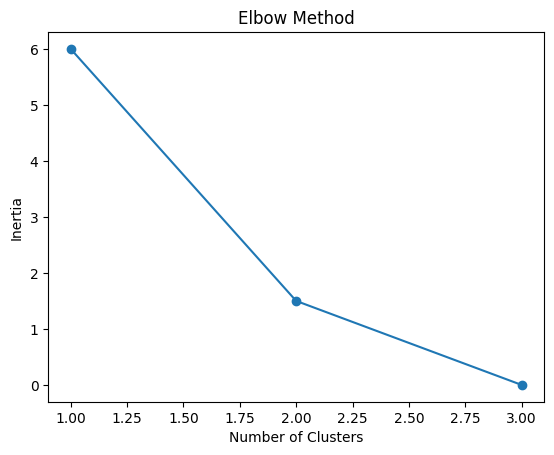

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

# Maximum clusters cannot exceed number of samples
max_k = min(10, len(X_scaled))
K = range(1, max_k + 1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = clusters

df.head()

,age,salary,Cluster
0,25,50000,2
1,30,60000,0
2,35,70000,1


Columns in dataframe:
age
salary
Cluster


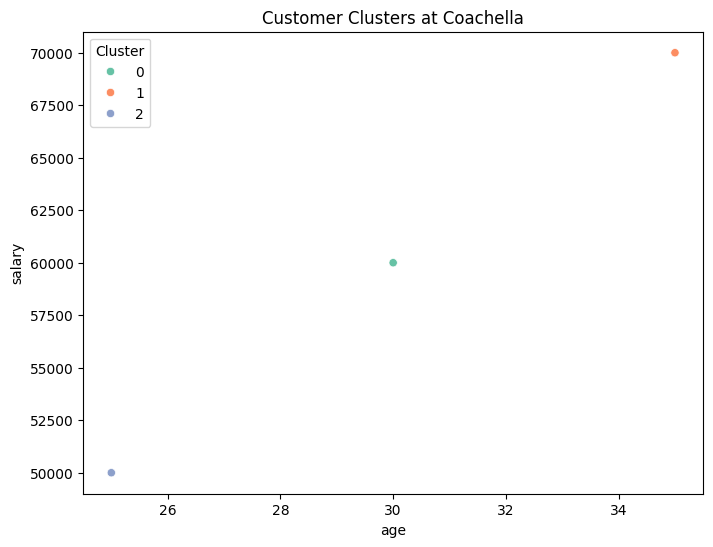

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Remove leading/trailing spaces in column names
df.columns = df.columns.str.strip()

# Show the real column names
print("Columns in dataframe:")
for col in df.columns:
    print(col)

# Example plot (CHANGE column names if needed after checking above)
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x=df.columns[0],   # first column (income-like column)
    y=df.columns[1],   # second column (ticket spending)
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Clusters at Coachella")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])

plt.show()

In [16]:
df.columns = df.columns.str.strip()

In [19]:
df.head()

,age,salary,Cluster
0,25,50000,2
1,30,60000,0
2,35,70000,1


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = {
    "size": [1000, 1200, 1500, 1800],
    "bedrooms": [2, 3, 3, 4],
    "price": [200000, 250000, 300000, 350000]
}

df = pd.DataFrame(data)

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train)
print(y_train)

   size  bedrooms
3  1800         4
0  1000         2
2  1500         3
3    350000
0    200000
2    300000
Name: price, dtype: int64


In [22]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
y_pred = model.predict(X_test)

In [25]:
print("Predicted labels:", np.unique(y_pred))
print("Actual labels:", np.unique(y_test))

Predicted labels: [200000]
Actual labels: [250000]


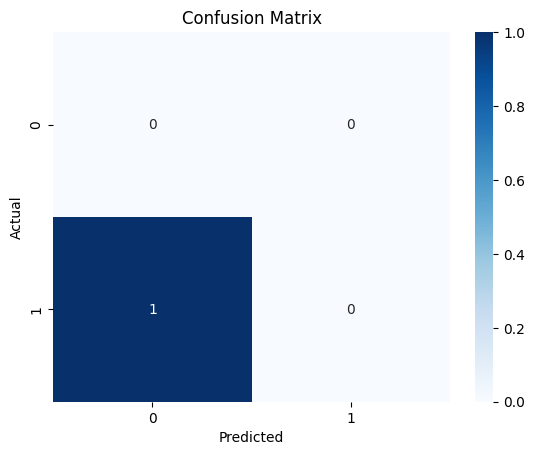

In [26]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
new_person = pd.DataFrame({
    'bedrooms':[3],
    'size':[1200]
})

new_person = new_person[model.feature_names_in_]

prediction = model.predict(new_person)